In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [2]:
import urllib.request
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
urllib.request.urlretrieve(url, "winequality-red.csv")
print("Dataset downloaded successfully!")

Dataset downloaded successfully!


#**Data collection**


In [3]:
wine_dataset = pd.read_csv("winequality-red.csv", sep=";")
wine_dataset.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
wine_dataset.shape

(1599, 12)

# **Data analyasis and visualisation**

In [5]:
wine_dataset.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


#**Creating a graph showing count of wines for each quality**

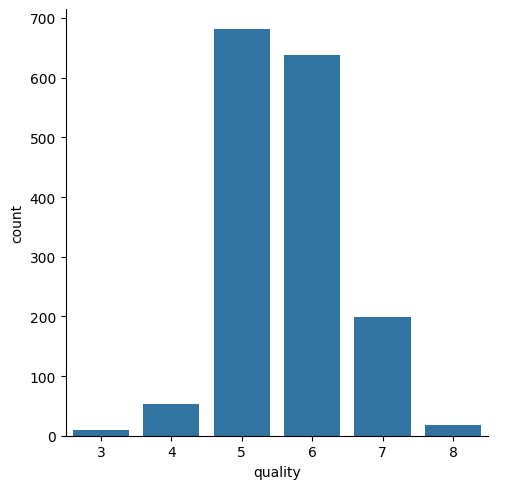

In [6]:
sns.catplot(x='quality' , data = wine_dataset ,kind ='count' )

# **Scatter plot of alcohol vs pH**

<Axes: xlabel='pH', ylabel='alcohol'>

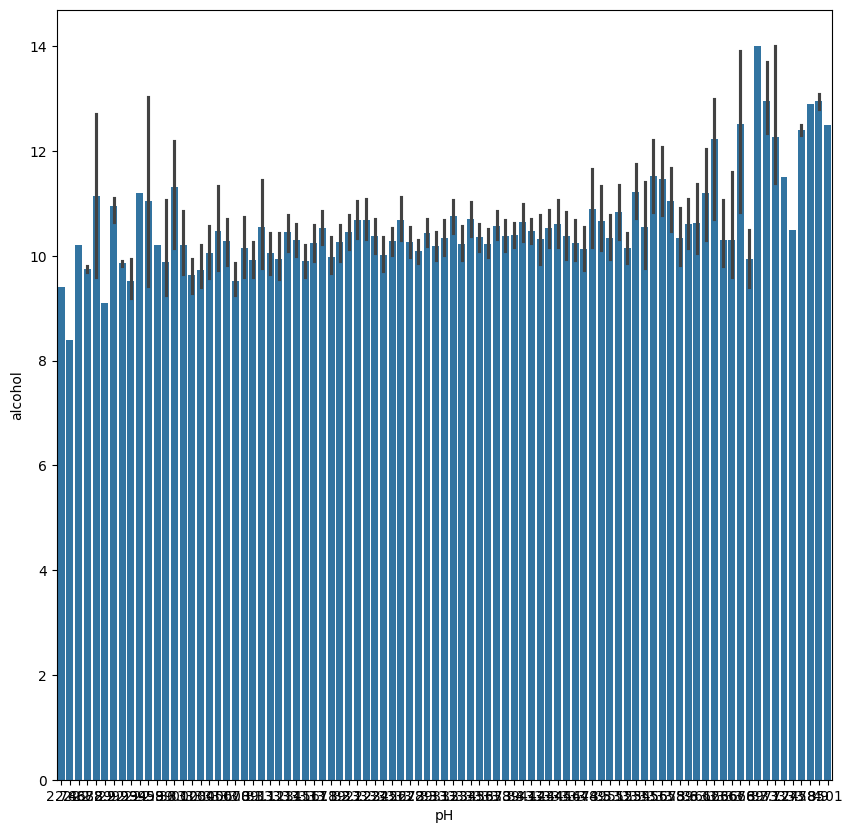

In [7]:
plot = plt.figure(figsize = (10,10))
sns.barplot(x='pH' , y = 'alcohol' , data = wine_dataset)

ABOUT CORRELATION: The points are scattered randomly with no discernible pattern, it suggests little to no correlation.

# **Histogram of alcohol**

<Axes: xlabel='alcohol', ylabel='Count'>

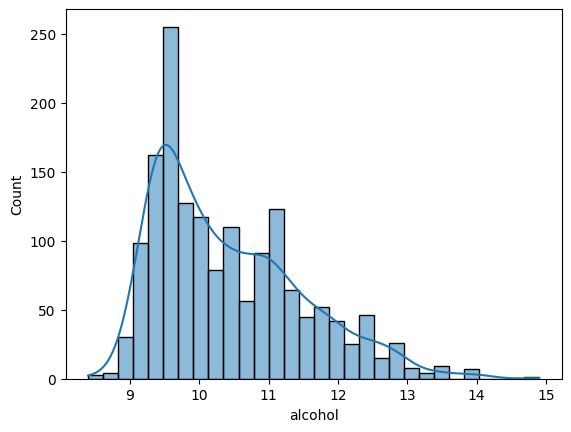

In [8]:
sns.histplot(wine_dataset,x='alcohol',bins=30,kde=True)

#**Boxplot to compare the spread of residual sugar grouped by quality score**

<Axes: xlabel='quality', ylabel='residual sugar'>

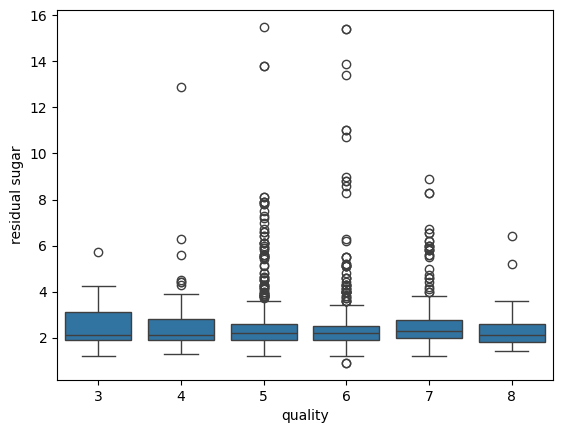

In [9]:

sns.boxplot(wine_dataset,x='quality', y='residual sugar')

# **Correlation matrix for entire dataset**

In [10]:
correlation = wine_dataset.corr()

<Axes: >

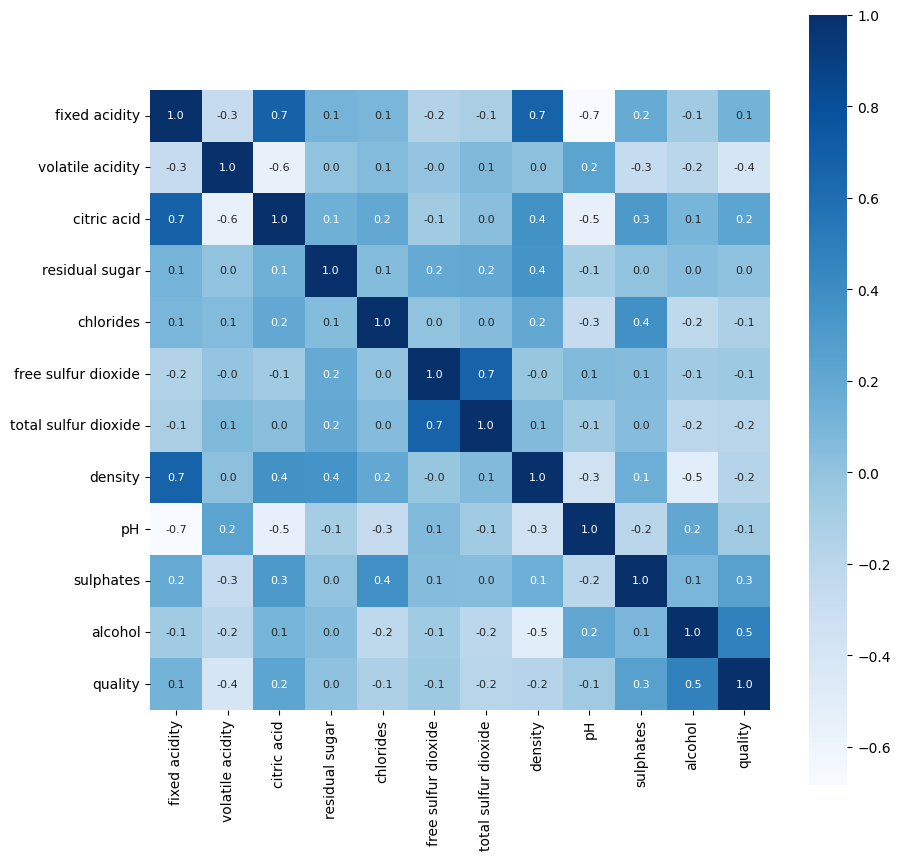

In [11]:

plt.figure(figsize=(10,10))
sns.heatmap(correlation, cbar=True , square= True, fmt = '.1f', annot = True, annot_kws={'size':8,}, cmap = 'Blues')

#**Lineplot of total sulphur dioxide againt free sulphur dioxide**

<Axes: xlabel='free sulfur dioxide', ylabel='total sulfur dioxide'>

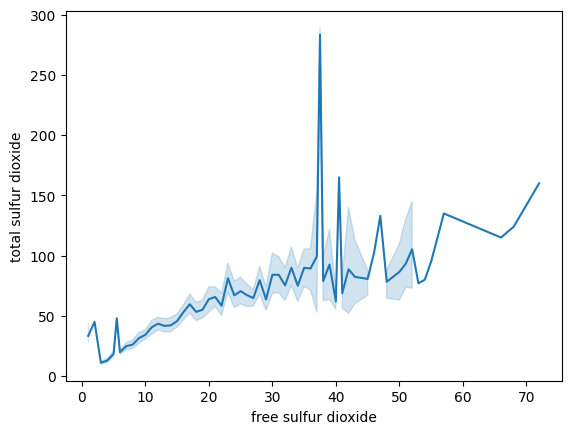

In [12]:
sns.lineplot(wine_dataset,x='free sulfur dioxide', y='total sulfur dioxide')

# **Bonus questions**


Basic Data Exploration

1. mean value of citric acid column

In [13]:
wine_dataset['citric acid'].dropna().mean()

0.2709756097560976

2.The minimum and maximum values for each numerical column

In [14]:
max_values=wine_dataset.max()
min_values=wine_dataset.min()
print(max_values)
print(min_values)

fixed acidity            15.90000
volatile acidity          1.58000
citric acid               1.00000
residual sugar           15.50000
chlorides                 0.61100
free sulfur dioxide      72.00000
total sulfur dioxide    289.00000
density                   1.00369
pH                        4.01000
sulphates                 2.00000
alcohol                  14.90000
quality                   8.00000
dtype: float64
fixed acidity           4.60000
volatile acidity        0.12000
citric acid             0.00000
residual sugar          0.90000
chlorides               0.01200
free sulfur dioxide     1.00000
total sulfur dioxide    6.00000
density                 0.99007
pH                      2.74000
sulphates               0.33000
alcohol                 8.40000
quality                 3.00000
dtype: float64


FILTERING AND CONDITIONAL LOGIC

Wines with pH greater than 3.5 and alcohol content greater than 10. Also their average quality

In [15]:
filtered_wine_dataset=wine_dataset[(wine_dataset['pH'] > 3.5) & (wine_dataset['alcohol'] > 10)]

average_quality = filtered_wine_dataset['quality'].mean()

print("filtered data:")
print(filtered_wine_dataset)
print(f"\naverage quality:{average_quality}")

filtered data:
      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
45              4.6             0.520         0.15             2.1      0.054   
75              8.8             0.410         0.64             2.2      0.093   
76              8.8             0.410         0.64             2.2      0.093   
77              6.8             0.785         0.00             2.4      0.104   
94              5.0             1.020         0.04             1.4      0.045   
...             ...               ...          ...             ...        ...   
1582            6.1             0.715         0.10             2.6      0.053   
1587            5.8             0.610         0.11             1.8      0.066   
1591            5.4             0.740         0.09             1.7      0.089   
1595            5.9             0.550         0.10             2.2      0.062   
1597            5.9             0.645         0.12             2.0      0.075   

      free s

GROUPING AND AGGREATION

1.The quality score which has highest alcohol content


In [16]:
highest_alcohol_content_row = wine_dataset.loc[wine_dataset['alcohol'].idxmax()]

highest_alcohol_content = highest_alcohol_content_row['alcohol']
quality_score = highest_alcohol_content_row['quality']

print(f"Highest Alcohol Content: {highest_alcohol_content}")
print(f"Quality Score: {quality_score}")

Highest Alcohol Content: 14.9
Quality Score: 5.0


2.Datasset grouped by quality column and the mean and medians of the other columns


In [17]:
grouped_by_quality = wine_dataset.groupby('quality').agg(['mean','median'])

print(grouped_by_quality)

        fixed acidity        volatile acidity        citric acid         \
                 mean median             mean median        mean median   
quality                                                                   
3            8.360000   7.50         0.884500  0.845    0.171000  0.035   
4            7.779245   7.50         0.693962  0.670    0.174151  0.090   
5            8.167254   7.80         0.577041  0.580    0.243686  0.230   
6            8.347179   7.90         0.497484  0.490    0.273824  0.260   
7            8.872362   8.80         0.403920  0.370    0.375176  0.400   
8            8.566667   8.25         0.423333  0.370    0.391111  0.420   

        residual sugar        chlorides          ... total sulfur dioxide  \
                  mean median      mean  median  ...                 mean   
quality                                          ...                        
3             2.635000    2.1  0.122500  0.0905  ...            24.900000   
4             2.

DATA CLEANING


1.No of null values in citric acid column and replacing them with the median value of that column


In [18]:
wine_dataset['citric acid'].isna().sum()

0

In [19]:
print(f"null values in 'citric acid' : {wine_dataset['citric acid'].isnull().sum()}")

wine_dataset['citric acid'].fillna(wine_dataset['citric acid'].median(), inplace=True)

print("updated 'citric acid' column:")

print(wine_dataset['citric acid'])

null values in 'citric acid' : 0
updated 'citric acid' column:
0       0.00
1       0.00
2       0.04
3       0.56
4       0.00
        ... 
1594    0.08
1595    0.10
1596    0.13
1597    0.12
1598    0.47
Name: citric acid, Length: 1599, dtype: float64


C:\Users\Asus\AppData\Local\Temp\ipykernel_47552\2360346437.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  wine_dataset['citric acid'].fillna(wine_dataset['citric acid'].median(), inplace=True)


2.Removing all rows where the residual sugar has null values

# **Model Building — Random Forest Classifier**

In [20]:
# Binarize quality: good wine (1) if quality >= 7, else bad (0)
wine_dataset["best quality"] = [1 if x >= 7 else 0 for x in wine_dataset["quality"]]

X = wine_dataset.drop(["quality", "best quality"], axis=1)
y = wine_dataset["best quality"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=3)
print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

Training samples: 1279, Test samples: 320


In [21]:
# Train the Random Forest model (max_depth and min_samples_leaf prevent overfitting)
model = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42)
model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


# **Model Evaluation**

In [22]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc  = accuracy_score(y_test,  model.predict(X_test))

print(f"Training Accuracy : {train_acc:.2f}")
print(f"Test Accuracy     : {test_acc:.2f}")

Training Accuracy : 0.94
Test Accuracy     : 0.92


In [23]:
# Classification report
print(classification_report(y_test, model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96       283
           1       0.72      0.49      0.58        37

    accuracy                           0.92       320
   macro avg       0.83      0.73      0.77       320
weighted avg       0.91      0.92      0.91       320



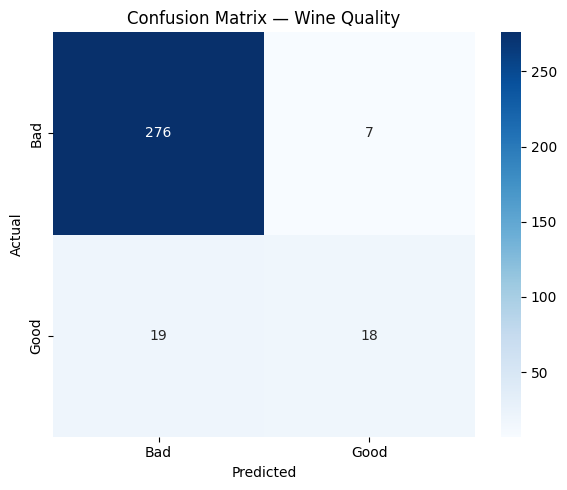

In [24]:
# Confusion Matrix
cm = confusion_matrix(y_test, model.predict(X_test))
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Bad","Good"], yticklabels=["Bad","Good"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Wine Quality")
plt.tight_layout()
plt.show()